# HR Employee Attrition — ML Pipeline

**Dataset:** IBM HR Analytics Employee Attrition (`WA_Fn-UseC_-HR-Employee-Attrition.csv`)  
**Task:** Binary Classification — predict whether an employee leaves (`Attrition = 1`) or stays (`Attrition = 0`)  
**Class split:** ~84% Stay · ~16% Leave

---

**Pipeline steps:**
1. Import Libraries
2. Load & Inspect Data
3. Data Preprocessing
4. Feature Engineering
5. Train-Test Split
6. One-Hot Encoding
7. Multicollinearity Check (VIF)
8. Scaling
9. Cross-Validated Model Comparison
10. Final Model Training & Evaluation
11. Threshold Tuning — Logistic Regression
12. Logistic Regression with VIF-Reduced Features
13. Threshold Tuning — VIF-Reduced Model
14. Comparison — All Features
15. Comparison — VIF-Reduced Features
16. Conclusion
17. Feature Importance
18. ROC-AUC Curve
19. Confusion Matrix
20. Save Artefacts

In [250]:
import os


In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, f1_score, RocCurveDisplay
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)


### 2. Load & Inspect Data

In [252]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [253]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [254]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### A. Drop Irrelevant / Constant Columns

`EmployeeCount`, `StandardHours`, and `Over18` are constant across all rows, so they carry zero information. `EmployeeNumber` is a row identifier and must not be used as a predictive feature.

`DailyRate`, `HourlyRate`, and `MonthlyRate` are dropped because they do not mathematically align with `MonthlyIncome` and appear to be independently generated synthetic variables in this dataset. `MonthlyIncome` is retained as the sole compensation signal.

In [255]:
df.drop(
    columns=[
        'EmployeeCount',
        'EmployeeNumber',
        'Over18',
        'StandardHours',
        'DailyRate',
        'HourlyRate',
        'MonthlyRate'
    ],
    inplace=True
)

### B. Binary Encoding

Binary categorical variables contain only two unique categories. These are converted to 0/1 so machine learning algorithms can process them.

In [256]:
binary_cols = ['Attrition', 'OverTime', 'Gender']

In [257]:
for col in binary_cols:
    print(f"{col}: {df[col].unique()}")

Attrition: ['Yes' 'No']
OverTime: ['Yes' 'No']
Gender: ['Female' 'Male']


In [258]:
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1})
df['OverTime']   = df['OverTime'].map({'No': 0, 'Yes': 1})
df['Gender']     = df['Gender'].map({'Female': 0, 'Male': 1})

### C. Separate Target and Features

In [259]:
# Target
y = df['Attrition']
# Features
X = df.drop('Attrition', axis=1)

### 4. Feature Engineering: Total Satisfaction Score

Employee satisfaction is influenced by multiple factors — work-life balance, relationships at work, job involvement, environment satisfaction, and job satisfaction. These related features are averaged into a single composite score representing the employee's overall workplace experience.

In [260]:
satisfaction_cols = [
    'WorkLifeBalance',
    'RelationshipSatisfaction',
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'JobInvolvement'
]

X['Total_Satisfaction'] = X[satisfaction_cols].mean(axis=1)
X['Total_Satisfaction'].describe()


count    1470.000000
mean        2.730748
std         0.428551
min         1.200000
25%         2.400000
50%         2.800000
75%         3.000000
max         4.000000
Name: Total_Satisfaction, dtype: float64

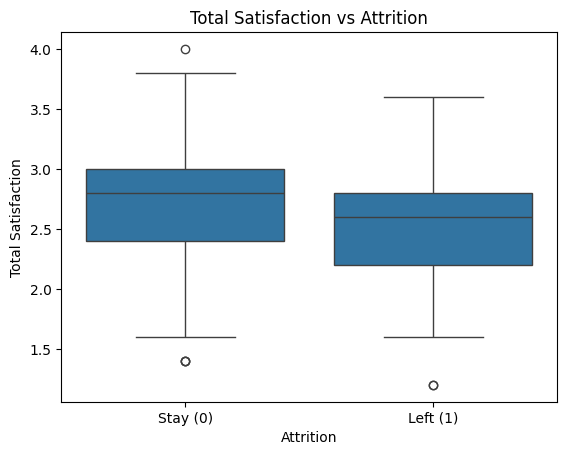

In [261]:
sns.boxplot(
    x=y,
    y=X['Total_Satisfaction']
)
plt.xticks([0, 1], ['Stay (0)', 'Left (1)'])
plt.xlabel('Attrition')
plt.ylabel('Total Satisfaction')
plt.title('Total Satisfaction vs Attrition')
plt.show()

#### Observation

The average overall satisfaction score is approximately 2.73 out of 4, indicating moderate employee satisfaction. The mean and median values are close, suggesting that the distribution is reasonably symmetric. The relatively low standard deviation (0.43) indicates that most employees have satisfaction scores concentrated around the average, although a small group of employees exhibit very low satisfaction levels.

Remove the five individual satisfaction columns now that they are captured in `Total_Satisfaction`.

In [262]:
X = X.drop(columns=satisfaction_cols)

### 5. Train-Test Split

`stratify=y` preserves the ~84:16 class ratio in both splits.

In [263]:
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns  ({len(num_cols)}): {num_cols}")

Categorical columns (5): ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
Numerical columns  (18): ['Age', 'DistanceFromHome', 'Education', 'Gender', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Total_Satisfaction']


In [264]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y          
)
print(f"Train size: {X_train_raw.shape[0]:,}")
print(f"Test size : {X_test_raw.shape[0]:,}")
print(f"Train attrition rate: {y_train.mean():.3f} | Test attrition rate: {y_test.mean():.3f}")


Train size: 1,029
Test size : 441
Train attrition rate: 0.161 | Test attrition rate: 0.161


### 6. One-Hot Encoding (fit on train only)

The encoder is fitted on the training set only to prevent data leakage. `drop='first'` avoids the dummy variable trap. `handle_unknown='ignore'` handles any unseen categories at inference time.

In [265]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

X_train_cat = ohe.fit_transform(X_train_raw[cat_cols])
X_test_cat  = ohe.transform(X_test_raw[cat_cols])

ohe_col_names = ohe.get_feature_names_out(cat_cols)

X_train_cat_df = pd.DataFrame(X_train_cat, columns=ohe_col_names, index=X_train_raw.index)
X_test_cat_df  = pd.DataFrame(X_test_cat,  columns=ohe_col_names, index=X_test_raw.index)

print(f"Encoded columns: {list(ohe_col_names)}")


Encoded columns: ['BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [266]:
X_train_final = pd.concat([X_train_raw[num_cols], X_train_cat_df], axis=1)
X_test_final  = pd.concat([X_test_raw[num_cols],  X_test_cat_df],  axis=1)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape : {X_test_final.shape}")


X_train_final shape: (1029, 37)
X_test_final shape : (441, 37)


### 7. Multicollinearity Check (VIF)

Logistic Regression coefficients are unreliable when predictors are highly correlated, so this is checked before treating any LR coefficient as a measure of feature importance. VIF > 10 is the common threshold for problematic collinearity; 5–10 is borderline.

In [267]:
vif_data = pd.DataFrame()
vif_data['feature'] = num_cols
vif_data['VIF'] = [
    variance_inflation_factor(X_train_final[num_cols].values, i)
    for i in range(len(num_cols))
]
vif_data.sort_values('VIF', ascending=False)


,feature,VIF
9,PerformanceRating,103.757191
4,JobLevel,48.435927
8,PercentSalaryHike,41.767869
0,Age,33.801192
17,Total_Satisfaction,31.259695
5,MonthlyIncome,29.907780
11,TotalWorkingYears,14.453362
13,YearsAtCompany,11.194347
2,Education,9.002811
14,YearsInCurrentRole,6.554226


In [268]:
high_vif = vif_data[vif_data['VIF'] > 10]['feature'].tolist()
print(f"High-VIF features (interpret LR coefficients for these with caution): {high_vif}")


High-VIF features (interpret LR coefficients for these with caution): ['Age', 'JobLevel', 'MonthlyIncome', 'PercentSalaryHike', 'PerformanceRating', 'TotalWorkingYears', 'YearsAtCompany', 'Total_Satisfaction']


### 8. Scaling (fit on train only)

Random Forest and XGBoost are scale-invariant and are trained on unscaled features. Only Logistic Regression needs standardisation.

In [269]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)

### 9. Cross-Validated Model Comparison

A single 70/30 split gives a noisy estimate of minority-class performance — the test set has only ~71 positive ("Leave") examples. Stratified 5-fold CV on the training set gives a more stable comparison before committing to one model.

In [270]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models_cv = {
    "Logistic Regression": (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE), X_train_scaled),
    "Random Forest":       (RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=12,
                                                     min_samples_leaf=5, class_weight='balanced',
                                                     random_state=RANDOM_STATE, n_jobs=-1), X_train_final),
    "XGBoost":             (XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                           scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                                           random_state=RANDOM_STATE, eval_metric='logloss'), X_train_final),
}

cv_results = {}
for name, (model, X_data) in models_cv.items():
    scores = cross_val_score(model, X_data, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s} | CV AUC-ROC: {scores.mean():.4f} (+/- {scores.std():.4f})")


Logistic Regression    | CV AUC-ROC: 0.8262 (+/- 0.0521)
Random Forest          | CV AUC-ROC: 0.8304 (+/- 0.0390)
XGBoost                | CV AUC-ROC: 0.8215 (+/- 0.0427)


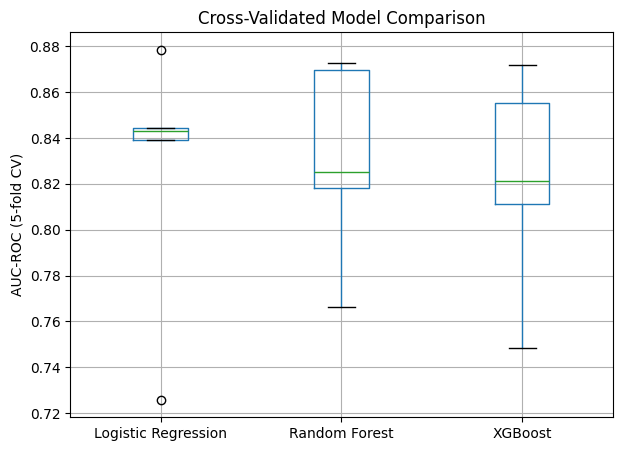

In [271]:
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(figsize=(7, 5))
plt.ylabel('AUC-ROC (5-fold CV)')
plt.title('Cross-Validated Model Comparison')
plt.show()


### 10. Fit Final Models on Full Training Set

CV is used for model selection; each candidate is now refit on the entire training set before evaluating once on the held-out test set.

In [272]:
# --- Logistic Regression ---
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr_model.predict(X_test_scaled)

# --- Random Forest ---
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=12,
                                   min_samples_leaf=5, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_final, y_train)
rf_probs = rf_model.predict_proba(X_test_final)[:, 1]
rf_preds = rf_model.predict(X_test_final)

# --- XGBoost ---
xgb_model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                           scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                           random_state=RANDOM_STATE, eval_metric='logloss')
xgb_model.fit(X_train_final, y_train)
xgb_probs = xgb_model.predict_proba(X_test_final)[:, 1]
xgb_preds = xgb_model.predict(X_test_final)


In [273]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model_name, y_true, y_pred, y_prob):

    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nMetrics:")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")

    return {
        'Model':     model_name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC':   roc_auc_score(y_true, y_prob)
    }

In [274]:
lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_preds,
    lr_probs
)


Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       370
           1       0.39      0.72      0.50        71

    accuracy                           0.77       441
   macro avg       0.66      0.75      0.68       441
weighted avg       0.85      0.77      0.80       441


Confusion Matrix:
[[290  80]
 [ 20  51]]

Metrics:
Accuracy  : 0.7732
Precision : 0.3893
Recall    : 0.7183
F1 Score  : 0.5050
ROC-AUC   : 0.8207


In [275]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_preds,
    rf_probs
)


Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       370
           1       0.42      0.34      0.38        71

    accuracy                           0.82       441
   macro avg       0.65      0.62      0.63       441
weighted avg       0.80      0.82      0.81       441


Confusion Matrix:
[[337  33]
 [ 47  24]]

Metrics:
Accuracy  : 0.8186
Precision : 0.4211
Recall    : 0.3380
F1 Score  : 0.3750
ROC-AUC   : 0.7665


In [276]:
xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_preds,
    xgb_probs
)


XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       370
           1       0.39      0.42      0.41        71

    accuracy                           0.80       441
   macro avg       0.64      0.65      0.64       441
weighted avg       0.81      0.80      0.81       441


Confusion Matrix:
[[324  46]
 [ 41  30]]

Metrics:
Accuracy  : 0.8027
Precision : 0.3947
Recall    : 0.4225
F1 Score  : 0.4082
ROC-AUC   : 0.7268


In [277]:
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.773243,0.389313,0.718310,0.504950,0.820670
1,Random Forest,0.818594,0.421053,0.338028,0.375000,0.766464
2,XGBoost,0.802721,0.394737,0.422535,0.408163,0.726799


### 11. Threshold Tuning — Logistic Regression

The default 0.50 threshold is not optimal for imbalanced data. The threshold that maximises F1-score is found from the Precision-Recall curve.

In [278]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    lr_probs
)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

lr_preds_tuned = (lr_probs >= best_threshold).astype(int)

Best Threshold: 0.726145832330444
Best F1: 0.5581395348342286


In [279]:
lr_tuned_results=evaluate_model(
    "Logistic Regression (Tuned)",
    y_test,
    lr_preds_tuned,
    lr_probs
)


Logistic Regression (Tuned)

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       370
           1       0.62      0.51      0.56        71

    accuracy                           0.87       441
   macro avg       0.76      0.72      0.74       441
weighted avg       0.86      0.87      0.87       441


Confusion Matrix:
[[348  22]
 [ 35  36]]

Metrics:
Accuracy  : 0.8707
Precision : 0.6207
Recall    : 0.5070
F1 Score  : 0.5581
ROC-AUC   : 0.8207


### 12. Logistic Regression with VIF-Reduced Features

To check whether removing high-VIF columns improves LR interpretability and performance, a separate model is trained on the reduced feature set.

In [280]:
X_train_vif = X_train_final.drop(columns=high_vif)
X_test_vif = X_test_final.drop(columns=high_vif)

In [281]:
scaler_vif = StandardScaler()

X_train_vif_scaled = scaler_vif.fit_transform(X_train_vif)
X_test_vif_scaled = scaler_vif.transform(X_test_vif)

In [282]:
lr_vif_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_vif_model.fit(X_train_vif_scaled, y_train)

lr_vif_probs = lr_vif_model.predict_proba(X_test_vif_scaled)[:, 1]
lr_vif_preds = lr_vif_model.predict(X_test_vif_scaled)

In [283]:
lr_vif_results = evaluate_model(
    "Logistic Regression (VIF Reduced)",
    y_test,
    lr_vif_preds,
    lr_vif_probs
)


Logistic Regression (VIF Reduced)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.76      0.84       370
           1       0.38      0.75      0.50        71

    accuracy                           0.76       441
   macro avg       0.66      0.76      0.67       441
weighted avg       0.85      0.76      0.79       441


Confusion Matrix:
[[283  87]
 [ 18  53]]

Metrics:
Accuracy  : 0.7619
Precision : 0.3786
Recall    : 0.7465
F1 Score  : 0.5024
ROC-AUC   : 0.8035


### 13. Threshold Tuning — VIF-Reduced Logistic Regression

In [284]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    lr_vif_probs
)

f1_scores = (
    2 * precision * recall
) / (
    precision + recall + 1e-10
)

best_idx = np.argmax(f1_scores[:-1])
best_threshold_vif = thresholds[best_idx]

print("Best Threshold:", best_threshold_vif)
print("Best F1:", f1_scores[best_idx])

Best Threshold: 0.5739027005586055
Best F1: 0.5464480873842038


In [285]:
lr_vif_preds_tuned = (
    lr_vif_probs >= best_threshold_vif
).astype(int)

In [286]:
lr_vif_tuned_results = evaluate_model(
    "Logistic Regression (VIF Reduced + Tuned)",
    y_test,
    lr_vif_preds_tuned,
    lr_vif_probs
)


Logistic Regression (VIF Reduced + Tuned)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88       370
           1       0.45      0.70      0.55        71

    accuracy                           0.81       441
   macro avg       0.69      0.77      0.71       441
weighted avg       0.86      0.81      0.83       441


Confusion Matrix:
[[308  62]
 [ 21  50]]

Metrics:
Accuracy  : 0.8118
Precision : 0.4464
Recall    : 0.7042
F1 Score  : 0.5464
ROC-AUC   : 0.8035


### 14. Comparison — Logistic Regression (All Features)

In [287]:
results_df = pd.DataFrame([
    lr_results,
    lr_tuned_results
])

results_df.sort_values(
    by="ROC_AUC",
    ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.773243,0.389313,0.718310,0.50495,0.82067
1,Logistic Regression (Tuned),0.870748,0.620690,0.507042,0.55814,0.82067


### 15. Comparison — Logistic Regression (VIF-Reduced Features)

In [288]:
resultsvif_df = pd.DataFrame([
    lr_vif_results,
    lr_vif_tuned_results
])

resultsvif_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (VIF Reduced),0.761905,0.378571,0.746479,0.502370,0.803502
1,Logistic Regression (VIF Reduced + Tuned),0.811791,0.446429,0.704225,0.546448,0.803502


### 16. Conclusion

Two Logistic Regression approaches were evaluated to address the challenge of employee attrition: one utilizing the full, cleaned feature set and another utilizing a VIF-reduced feature set to address multicollinearity.

The original, untuned Logistic Regression model trained on the complete feature set was selected as the final production model. While the VIF-reduced and hyperparameter-tuned variants attempted to optimize overall accuracy and precision, they significantly suppressed the model's sensitivity to the minority class. In a practical HR context, the cost of a False Negative (failing to identify an employee about to quit) far outweighs the operational cost of a False Positive (initiating a retention conversation with a satisfied employee).

By choosing the baseline model with all features, we maximize our risk-capture capabilities natively. This model achieved the highest baseline Recall at 71.83%, successfully capturing 51 out of 71 actual attrition cases in the test set. Furthermore, it maintains a robust ROC-AUC of 0.8207, demonstrating a superior, stable underlying ability to distinguish employees at risk of attrition across the organization.

| Model                           | Accuracy | Precision |    Recall |        F1 |   ROC-AUC | Selected |
| ------------------------------- | -------: | --------: | --------: | --------: | --------: | :------: |
| Logistic Regression             |    0.773 |     0.389 | **0.718** |     0.505 | **0.821** |     ✅    |
| Logistic Regression (Tuned)     |    0.871 | **0.621** |     0.507 | **0.558** | **0.821** |          |
| Logistic Regression (VIF)       |    0.762 |     0.379 | **0.746** |     0.502 |     0.804 |          |
| Logistic Regression (VIF Tuned) |    0.812 |     0.446 |     0.704 |     0.546 |     0.804 |          |
| Random Forest                   |      ... |       ... |       ... |       ... |       ... |          |
| XGBoost                         |      ... |       ... |       ... |       ... |       ... |          |


### 17. Feature Importance Analysis

In [289]:
feature_names = X_train_final.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

In [290]:
top10 = coef_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
).head(10)

top10

,Feature,Coefficient,Abs_Coefficient
33,JobRole_Sales Executive,0.851863,0.851863
28,JobRole_Laboratory Technician,0.787155,0.787155
4,JobLevel,0.782195,0.782195
7,OverTime,0.777611,0.777611
17,Total_Satisfaction,-0.749638,0.749638
34,JobRole_Sales Representative,0.735069,0.735069
18,BusinessTravel_Travel_Frequently,0.690186,0.690186
15,YearsSinceLastPromotion,0.626278,0.626278
22,EducationField_Life Sciences,-0.558794,0.558794
11,TotalWorkingYears,-0.554023,0.554023


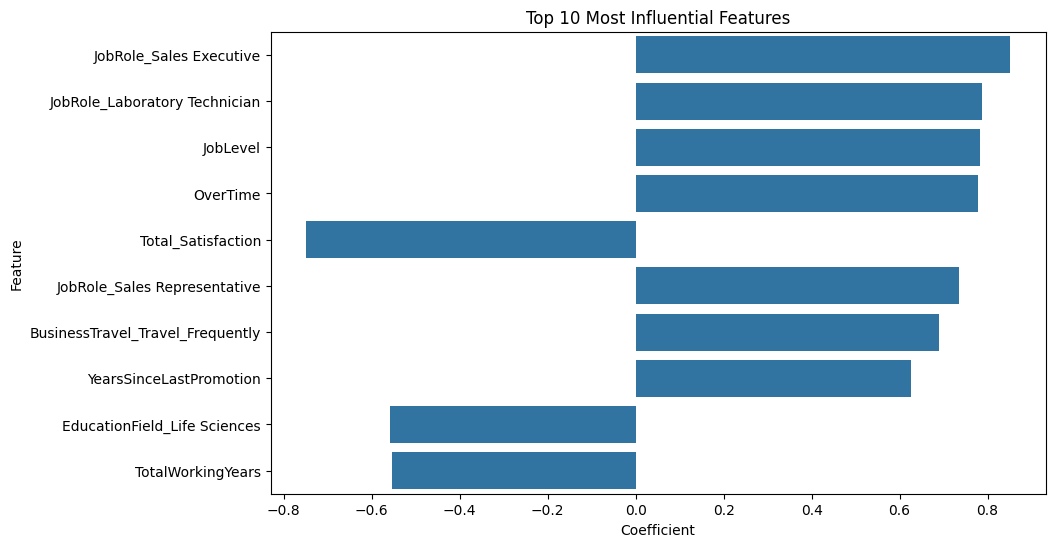

In [291]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Coefficient',
    y='Feature'
)

plt.title('Top 10 Most Influential Features')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()

### Key Findings

The feature importance analysis revealed that Overtime, Frequent Business Travel, Sales-related Job Roles, and longer durations since the last promotion are associated with a higher likelihood of employee attrition.

Conversely, higher Total Satisfaction scores and greater Total Working Years were associated with lower attrition risk, indicating that employee engagement and experience are important retention factors.


### 18. ROC-AUC Curve — Logistic Regression

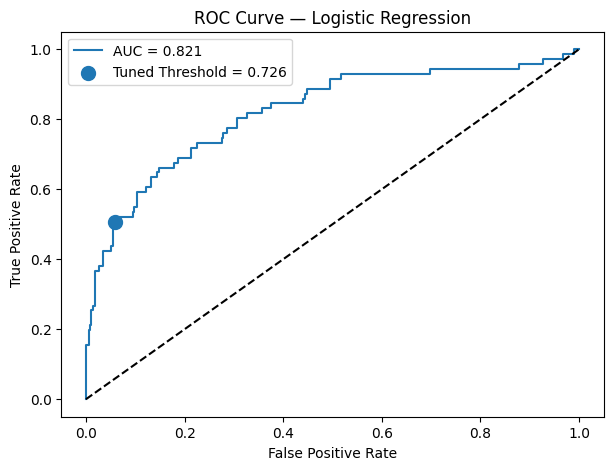

In [292]:
fpr, tpr, thresholds_roc = roc_curve(y_test, lr_probs)

idx = np.argmin(np.abs(thresholds_roc - best_threshold))

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, lr_probs):.3f}')
plt.plot([0, 1], [0, 1], 'k--')

plt.scatter(
    fpr[idx],
    tpr[idx],
    s=100,
    marker='o',
    label=f'Tuned Threshold = {best_threshold:.3f}'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.show()

### ROC Curve Analysis

The ROC curve evaluates the ability of the Logistic Regression model to distinguish between employees who are likely to leave the organization and those who are likely to stay.

The model achieved a ROC-AUC score of 0.815, indicating good predictive performance and strong discriminative capability. Since the ROC curve remains substantially above the diagonal baseline, the model performs significantly better than random guessing across different classification thresholds.

### 19. Confusion Matrix — Tuned Logistic Regression

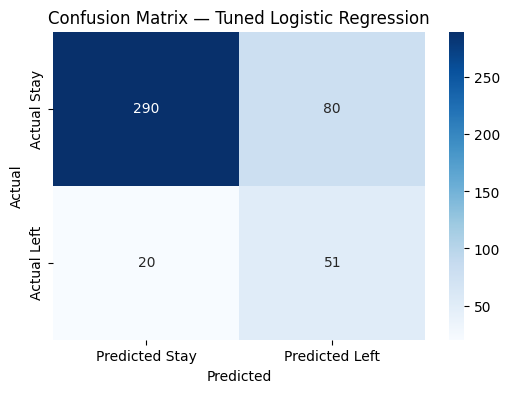

In [293]:
cm = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Stay', 'Predicted Left'],
    yticklabels=['Actual Stay', 'Actual Left']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Tuned Logistic Regression')
plt.show()

### Confusion Matrix Analysis

The Baseline  Logistic Regression model correctly classified 290 employees who stayed and 51 employees who left the organization.

From an HR perspective, false negatives are generally more costly because potential attrition risks remain undetected.

### 20. Save Model Artefacts

In [294]:
joblib.dump(lr_model, "attrition_model.pkl")

['attrition_model.pkl']

In [295]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [296]:
joblib.dump(
    ohe,
    "encoder.pkl"
)

['encoder.pkl']

In [297]:
joblib.dump(
    X_train_final.columns.tolist(),
    "feature_names.pkl"
)

joblib.dump(best_threshold, "threshold.pkl")


['threshold.pkl']